<a href="https://colab.research.google.com/github/juanjo9926/INTELIGENCIA-ARTIFICIAL-1/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Redes Neuronales - Reconocimiento de Dígitos Manuscritos USPSIntroducción
Se implementa una red neuronal para reconocer dígitos manuscritos utilizando el dataset USPS. A diferencia del ejercicio original que usaba MNIST con imágenes de 20×20 píxeles, este dataset contiene imágenes de 16×16 píxeles con 1100 ejemplos por cada uno de los 10 dígitos, dando un total de 11000 ejemplos de entrenamiento.La red neuronal implementada tiene 3 capas:

Capa de entrada: 256 neuronas (píxeles de imagen 16×16)
Capa oculta: 25 neuronas
Capa de salida: 10 neuronas (dígitos del 0 al 9)

In [ ]:
# utilizado para manipular rutas y directorios
import os

# Computación cientifica y vectorial para Python
import numpy as np

# Libreria para gráficos
from matplotlib import pyplot

# Modulo de optimización
from scipy import optimize

# Modulo para cargar archivos de datos en formato MATLAB
from scipy.io import loadmat

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Descripción
El dataset usps_all.mat contiene dígitos manuscritos del sistema postal de Estados Unidos (USPS). Su estructura original es (256, 1100, 10) donde:

256 = píxeles por imagen (imágenes de 16×16)
1100 = ejemplos por cada dígito
10 = clases (dígitos del 0 al 9)

In [ ]:
# Cargamos el dataset
data = loadmat('/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/usps_all.mat')

# Exploramos su estructura
for key in data.keys():
    if not key.startswith('__'):
        print(f"Variable: '{key}'")
        print(f"  Shape : {data[key].shape}")
        print(f"  Dtype : {data[key].dtype}")

Variable: 'data'
  Shape : (256, 1100, 10)
  Dtype : uint8


Reorganización al Formato Estándar
Se reorganiza el dataset del formato original (256, 1100, 10) al formato estándar X (11000, 256) y y (11000,) que requiere la red neuronal. Además se normalizan los píxeles al rango [0, 1].

In [ ]:
raw = data['data']  # shape: (256, 1100, 10)

X_list = []
y_list = []

for clase in range(10):
    # raw[:, :, clase] tiene shape (256, 1100) → trasponemos a (1100, 256)
    X_clase = raw[:, :, clase].T
    X_list.append(X_clase)
    y_list.append(np.full(1100, clase))

# Concatenamos todas las clases
X = np.concatenate(X_list, axis=0)   # (11000, 256)
y = np.concatenate(y_list, axis=0)   # (11000,)

# Normalizamos píxeles al rango [0, 1]
X = X.astype(float) / 255.0

m = y.size

print("=== DATASET LISTO ===")
print(f"Shape de X : {X.shape}")
print(f"Shape de y : {y.shape}")
print(f"Clases     : {np.unique(y)}")
print(f"Total (m)  : {m}")

=== DATASET LISTO ===
Shape de X : (11000, 256)
Shape de y : (11000,)
Clases     : [0 1 2 3 4 5 6 7 8 9]
Total (m)  : 11000


Visualización de los Datos
Se definen las funciones auxiliares y se visualizan 100 imágenes aleatorias del dataset para verificar que los datos están correctamente cargados.

Etiquetas de las primeras 10 imágenes: [0 0 7 8 4 3 5 0 1 2]


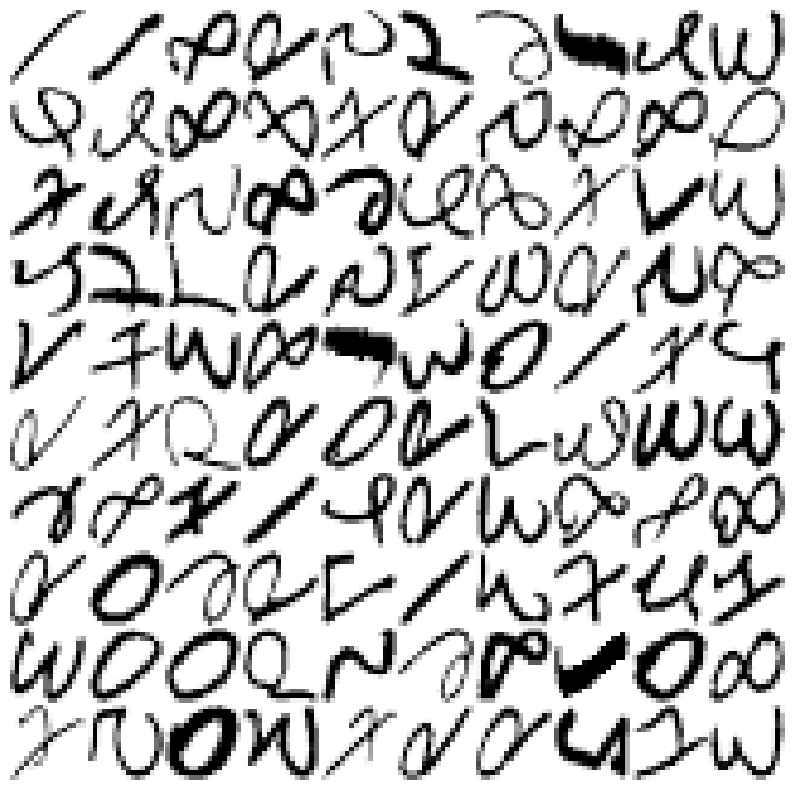

In [ ]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula apropiada.
    """
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensional.')

    # Para 256 píxeles → imagen de 16x16
    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        # Reshape a 16x16 (orden C, no F, porque USPS no es MATLAB-origin)
        ax.imshow(X[i].reshape(example_width, example_width, order='C'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

def sigmoid(z):
    """
    Calcula la función sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

# Seleccionamos 100 imágenes aleatorias para visualizar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

print("Etiquetas de las primeras 10 imágenes:", y[rand_indices[:10]])
displayData(sel)

**Representación del Modelo**
Configuración de la Red Neuronal
La red neuronal tiene la siguiente arquitectura:

Capa de entrada: 256 neuronas (imagen 16×16)
Capa oculta: 25 neuronas
Capa de salida: 10 neuronas (una por cada dígito)

Los pesos Theta1 (25×257) y Theta2 (10×26) incluyen la columna extra del término de bias.

In [ ]:
# Configuración de parámetros
input_layer_size  = 256  # Imagen de 16x16 píxeles
hidden_layer_size = 25   # 25 unidades ocultas
num_labels        = 10   # 10 etiquetas, del 0 al 9

print("=== CONFIGURACIÓN DE LA RED NEURONAL ===")
print(f"Capa de entrada : {input_layer_size} neuronas")
print(f"Capa oculta     : {hidden_layer_size} neuronas")
print(f"Capa de salida  : {num_labels} neuronas")

# Inicialización aleatoria de pesos con epsilon pequeño para romper simetría
epsilon = 0.12
np.random.seed(42)
Theta1 = np.random.uniform(-epsilon, epsilon, (hidden_layer_size, input_layer_size + 1))
Theta2 = np.random.uniform(-epsilon, epsilon, (num_labels, hidden_layer_size + 1))

print(f"\nShape de Theta1 : {Theta1.shape}  (esperado: 25 x 257)")
print(f"Shape de Theta2 : {Theta2.shape}  (esperado: 10 x 26)")

=== CONFIGURACIÓN DE LA RED NEURONAL ===
Capa de entrada : 256 neuronas
Capa oculta     : 25 neuronas
Capa de salida  : 10 neuronas

Shape de Theta1 : (25, 257)  (esperado: 25 x 257)
Shape de Theta2 : (10, 26)  (esperado: 10 x 26)


Propagación Hacia Adelante y Predicción
La propagación hacia adelante consiste en pasar los datos de entrada por cada capa de la red aplicando los pesos y la función sigmoide hasta obtener una predicción. Con pesos aleatorios la precisión será aproximadamente del 10%, equivalente a adivinar al azar entre 10 clases.

In [ ]:
def predict(Theta1, Theta2, X):
    """
    Realiza la propagación hacia adelante y devuelve
    el dígito predicho para cada ejemplo.
    """
    if X.ndim == 1:
        X = X[None]

    m = X.shape[0]

    # Capa de entrada → capa oculta
    X_bias = np.concatenate([np.ones((m, 1)), X], axis=1)  # (m, 257)
    a2 = sigmoid(X_bias.dot(Theta1.T))                      # (m, 25)

    # Capa oculta → capa de salida
    a2_bias = np.concatenate([np.ones((a2.shape[0], 1)), a2], axis=1)  # (m, 26)
    a3 = sigmoid(a2_bias.dot(Theta2.T))                                 # (m, 10)

    # La predicción es el índice de la neurona con mayor activación
    p = np.argmax(a3, axis=1)
    return p

# Probamos con pesos aleatorios
pred = predict(Theta1, Theta2, X)
print(f"Precisión con pesos aleatorios: {np.mean(pred == y) * 100:.1f}%")
print("(~10% es normal, aún no hemos entrenado la red)")

Precisión con pesos aleatorios: 10.0%
(~10% es normal, aún no hemos entrenado la red)


**Entrenamiento de la Red Neuronal**
Función de Costo y Backpropagation
Para entrenar la red se necesitan dos componentes: la función de costo que mide qué tan equivocada está la red, y el backpropagation que calcula cómo ajustar los pesos para reducir ese error. Se incluye regularización para evitar sobreajuste y estabilidad numérica para evitar log(0).

In [ ]:
def costFunction(nn_params, input_layer_size, hidden_layer_size, num_labels, X, y, lambda_=0.0):
    """
    Calcula el costo y los gradientes de la red neuronal
    usando backpropagation.
    """
    Theta1 = nn_params[:hidden_layer_size * (input_layer_size + 1)].reshape(
                hidden_layer_size, input_layer_size + 1)
    Theta2 = nn_params[hidden_layer_size * (input_layer_size + 1):].reshape(
                num_labels, hidden_layer_size + 1)

    m = X.shape[0]

    # ===== PROPAGACIÓN HACIA ADELANTE =====
    a1 = np.concatenate([np.ones((m, 1)), X], axis=1)

    z2 = a1.dot(Theta1.T)
    a2 = sigmoid(z2)
    a2 = np.concatenate([np.ones((a2.shape[0], 1)), a2], axis=1)

    z3 = a2.dot(Theta2.T)
    a3 = sigmoid(z3)

    # One-hot encoding: y=3 → [0,0,0,1,0,0,0,0,0,0]
    Y = np.zeros((m, num_labels))
    for i in range(m):
        Y[i, y[i]] = 1

    # ===== COSTO CON ESTABILIDAD NUMÉRICA =====
    eps = 1e-10  # Evita log(0)
    J = (-1 / m) * np.sum(Y * np.log(a3 + eps) + (1 - Y) * np.log(1 - a3 + eps))

    # Regularización (no se aplica al bias)
    reg = (lambda_ / (2 * m)) * (
        np.sum(Theta1[:, 1:] ** 2) +
        np.sum(Theta2[:, 1:] ** 2)
    )
    J = J + reg

    # ===== BACKPROPAGATION =====
    delta3 = a3 - Y
    delta2 = delta3.dot(Theta2[:, 1:]) * (a2[:, 1:] * (1 - a2[:, 1:]))

    Theta2_grad = (1 / m) * delta3.T.dot(a2)
    Theta1_grad = (1 / m) * delta2.T.dot(a1)

    # Regularización de gradientes
    Theta2_grad[:, 1:] += (lambda_ / m) * Theta2[:, 1:]
    Theta1_grad[:, 1:] += (lambda_ / m) * Theta1[:, 1:]

    grad = np.concatenate([Theta1_grad.ravel(), Theta2_grad.ravel()])
    return J, grad

División del Dataset y Entrenamiento
Se divide el dataset en 80% para entrenamiento y 20% para prueba, lo cual permite evaluar si la red generaliza correctamente a datos nuevos que nunca vio durante el entrenamiento.

In [ ]:
# División 80% entrenamiento / 20% prueba
np.random.seed(42)
indices_shuffle = np.random.permutation(m)
split = int(0.8 * m)

X_train = X[indices_shuffle[:split]]
y_train = y[indices_shuffle[:split]]
X_test  = X[indices_shuffle[split:]]
y_test  = y[indices_shuffle[split:]]

print("=== DIVISIÓN DEL DATASET ===")
print(f"Entrenamiento : {X_train.shape[0]} ejemplos (80%)")
print(f"Prueba        : {X_test.shape[0]}  ejemplos (20%)")

# Re-inicializamos pesos
epsilon = 0.12
np.random.seed(42)
Theta1 = np.random.uniform(-epsilon, epsilon, (hidden_layer_size, input_layer_size + 1))
Theta2 = np.random.uniform(-epsilon, epsilon, (num_labels, hidden_layer_size + 1))
nn_params = np.concatenate([Theta1.ravel(), Theta2.ravel()])

# Entrenamiento
print("\nEntrenando la red neuronal... (puede tardar 2-5 minutos)")
print("="*50)

result = optimize.minimize(
    fun=costFunction,
    x0=nn_params,
    args=(input_layer_size, hidden_layer_size, num_labels, X_train, y_train, 1.0),
    method='TNC',
    jac=True,
    options={'maxfun': 400, 'disp': True}
)

nn_params_trained = result.x

Theta1_trained = nn_params_trained[:hidden_layer_size * (input_layer_size + 1)].reshape(
                    hidden_layer_size, input_layer_size + 1)
Theta2_trained = nn_params_trained[hidden_layer_size * (input_layer_size + 1):].reshape(
                    num_labels, hidden_layer_size + 1)

print(f"\nCosto final  : {result.fun:.4f}")
print(f"Iteraciones  : {result.nit}")

=== DIVISIÓN DEL DATASET ===
Entrenamiento : 8800 ejemplos (80%)
Prueba        : 2200  ejemplos (20%)

Entrenando la red neuronal... (puede tardar 2-5 minutos)


/tmp/ipykernel_15695/956811816.py:36: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))



Costo final  : 0.1829
Iteraciones  : 25


**Evaluación y Resultados**

In [ ]:
pred_train = predict(Theta1_trained, Theta2_trained, X_train)
pred_test  = predict(Theta1_trained, Theta2_trained, X_test)

print("=== EVALUACIÓN DEL MODELO ===")
print(f"Precisión en entrenamiento : {np.mean(pred_train == y_train) * 100:.1f}%")
print(f"Precisión en prueba        : {np.mean(pred_test  == y_test)  * 100:.1f}%")
print("(Si entrenamiento >> prueba hay sobreajuste)")

=== EVALUACIÓN DEL MODELO ===
Precisión en entrenamiento : 99.9%
Precisión en prueba        : 96.1%
(Si entrenamiento >> prueba hay sobreajuste)


Predicción Individual
Se muestra una imagen a la vez con su etiqueta real y la predicción de la red. Se puede ejecutar varias veces para ver distintos ejemplos.

Etiqueta real            : 7
Predicción de la red     : 4
¿Correcto?: ✗ NO


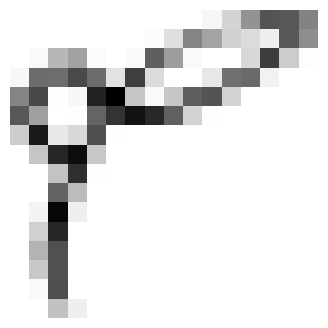

In [ ]:
indices = np.random.permutation(X_test.shape[0])

if indices.size > 0:
    i, indices = indices[0], indices[1:]
    print(f"Etiqueta real            : {y_test[i]}")
    displayData(X_test[i, :], figsize=(4, 4))
    pred_individual = predict(Theta1_trained, Theta2_trained, X_test[i, :])
    print(f"Predicción de la red     : {pred_individual[0]}")
    print(f"¿Correcto?: {'✓ SÍ' if pred_individual[0] == y_test[i] else '✗ NO'}")
else:
    print('No hay mas imagenes para mostrar!')

Visualización Múltiple con Predicciones
Se muestran 25 imágenes del conjunto de prueba con su etiqueta real y predicción. En verde las correctas y en rojo las incorrectas.

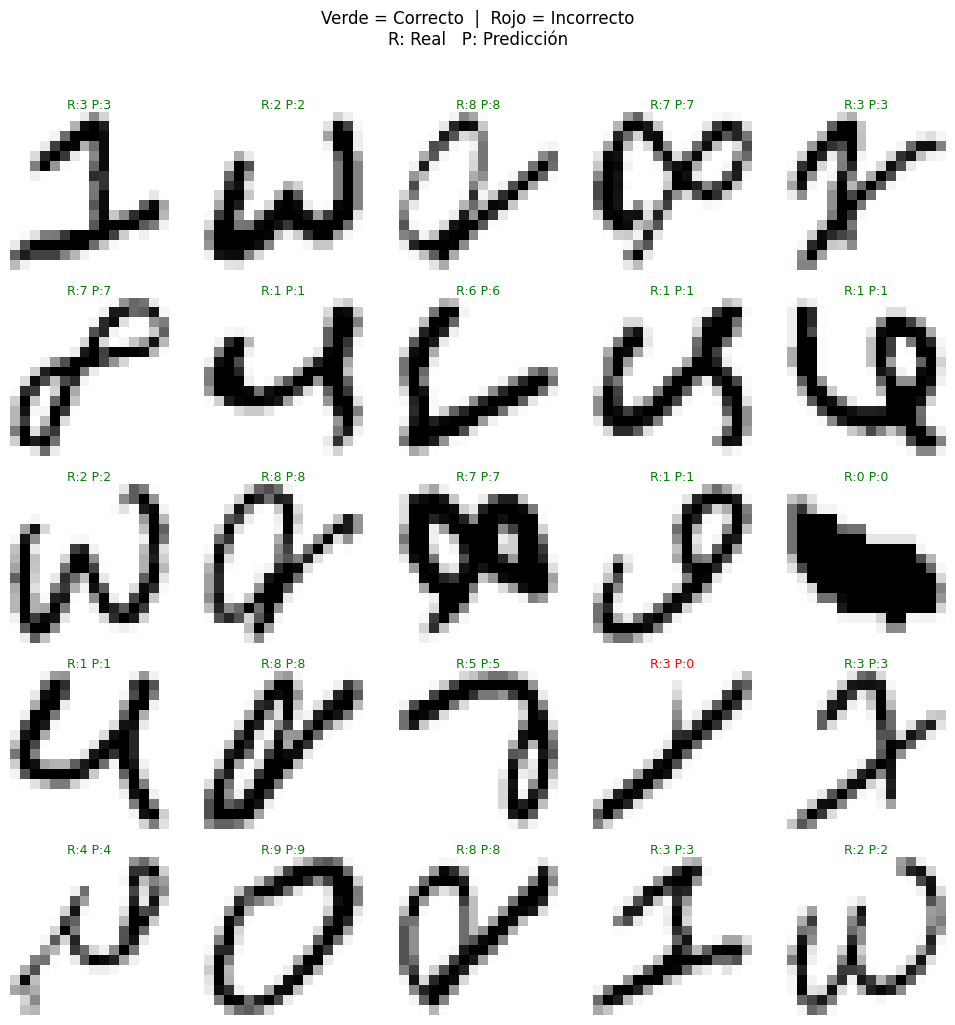

In [ ]:
n_mostrar = 25
rand_idx = np.random.choice(X_test.shape[0], n_mostrar, replace=False)
predicciones = predict(Theta1_trained, Theta2_trained, X_test[rand_idx])

fig, ax_array = pyplot.subplots(5, 5, figsize=(10, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.6)

for idx, ax in enumerate(ax_array.ravel()):
    i = rand_idx[idx]
    ax.imshow(X_test[i].reshape(16, 16, order='C'), cmap='Greys')
    ax.axis('off')
    real  = y_test[i]
    pred  = predicciones[idx]
    color = 'green' if pred == real else 'red'
    ax.set_title(f'R:{real} P:{pred}', fontsize=9, color=color, pad=2)

pyplot.suptitle('Verde = Correcto  |  Rojo = Incorrecto\nR: Real   P: Predicción',
                fontsize=12, y=1.02)
pyplot.tight_layout()
pyplot.show()

In [ ]:
print("========== RESUMEN FINAL DEL PROYECTO ==========")
print(f"Dataset         : USPS dígitos manuscritos")
print(f"Total ejemplos  : {m}")
print(f"Entrenamiento   : {X_train.shape[0]} ejemplos (80%)")
print(f"Prueba          : {X_test.shape[0]}  ejemplos (20%)")
print(f"Arquitectura    : {input_layer_size} → {hidden_layer_size} → {num_labels}")
print(f"─────────────────────────────────────────────────")
print(f"Precisión entrenamiento : {np.mean(predict(Theta1_trained, Theta2_trained, X_train) == y_train)*100:.1f}%")
print(f"Precisión prueba        : {np.mean(predict(Theta1_trained, Theta2_trained, X_test)  == y_test )*100:.1f}%")
print(f"─────────────────────────────────────────────────")
print(f"Código original (ex3data1) : 87.6%")
print(f"Nuestra red (USPS)         : {np.mean(predict(Theta1_trained, Theta2_trained, X_test) == y_test)*100:.1f}%")
print(f"=================================================")

========== RESUMEN FINAL DEL PROYECTO ==========
Dataset         : USPS dígitos manuscritos
Total ejemplos  : 11000
Entrenamiento   : 8800 ejemplos (80%)
Prueba          : 2200  ejemplos (20%)
Arquitectura    : 256 → 25 → 10
─────────────────────────────────────────────────
Precisión entrenamiento : 99.9%
Precisión prueba        : 96.1%
─────────────────────────────────────────────────
Código original (ex3data1) : 87.6%
Nuestra red (USPS)         : 96.1%
